# Labels Forecasting Project

## Introduction

This project was built to introduce the first structured forecasting process for label demand in a retail supermarket distribution center. Before this work, planning was mostly reactive. Decisions were based on recent sales, recent orders, visible shortages, and manual judgment. That approach can work in the short term, but it is difficult to scale, difficult to validate, and hard to use consistently across a large SKU catalog.

The goal was not to produce a perfect forecast or treat model output as absolute truth. In this process, the forecast acts as a demand signal that supports downstream operational decisions. That signal feeds into blank label purchasing, label printing, and pre-applying labels to selected containers. In other words, the value of the forecast comes from improving planning decisions, not from pretending it can capture demand with complete precision.

That distinction matters because the cost of error is not symmetric. Labels are relatively inexpensive, require little storage space, and can tolerate controlled overstock. Understock is much more disruptive. If labels are not available, products may not be sent to stores in a sellable condition, which can create lost sales, operational scrambling, and overtime. Because of that, the project is designed around building a reliable and healthy demand signal rather than minimizing error in the abstract.

The main analytical challenge is that the data is noisy and the catalog is highly mixed. Some SKUs behave steadily, while others are intermittent, seasonal, or close to inactive. On top of that, there is no single clean measure of demand. Orders and sales each capture part of the picture, but neither one is a perfect standalone target. That makes this project as much about defining demand properly as it is about selecting forecasting methods.

Since this was the first forecasting layer for the process, the priority was to start with methods that were practical, interpretable, and strong enough to create immediate value. The objective was to build a forecast framework that could support operational decisions now, while also creating a foundation for more advanced forecasting work later.

One important note before starting. This public version uses synthetic data built from the structure of the original project. The real project was based on internal company data, so for privacy reasons the SKU ids, dates, and volumes shown here are not the real ones. The modeling problem and the workflow are still the same.

## Load the data

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

data_candidates = [
    Path("../synthetic_data/synthetic_events.csv"),
    Path("synthetic_data/synthetic_events.csv"),
]

for data_path in data_candidates:
    if data_path.exists():
        break
else:
    raise FileNotFoundError("Could not find synthetic_events.csv from the current notebook location.")

events_df = pd.read_csv(data_path, dtype={"Sku": str}, parse_dates=["Date"])

events_df.head()

,Sku,Period,Date,Ordered,Sold
0,SKU_0632,2021-01,2021-01-01,0.0,0.0
1,SKU_0632,2021-02,2021-02-01,0.0,0.0
2,SKU_0632,2021-03,2021-03-01,0.0,0.0
3,SKU_0632,2021-04,2021-04-01,0.0,0.0
4,SKU_0632,2021-05,2021-05-01,0.0,0.0


## First checks

Before moving into forecasting, the first step is to understand the shape and quality of the available demand signals. Since this project starts from operational data rather than from a clean forecasting dataset, an initial review is necessary to confirm what the data is actually capturing and where its limitations may be.

At this stage, the objective is not yet to choose a model. The objective is to evaluate whether the series contains a usable planning signal, how much variability is present, and how demand behaves across products. This is especially important in a retail setting, where some SKUs move steadily while others are highly irregular, seasonal, or close to inactive.

These first checks help answer a few practical questions. Is demand stable enough to support a forecasting process? Are there visible patterns or structural differences across products? How noisy is the historical record? And just as important, what should be treated as true demand in a process where sales and orders each reflect only part of the picture?

This step sets the foundation for the rest of the notebook. The decisions made later around target construction, segmentation, and model choice depend on having a clear view of the behavior and limitations of the raw data.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
events_df["Period"] = pd.PeriodIndex(events_df["Period"], freq="M")

In [3]:
panel_summary = pd.DataFrame(
    {
        "metric": [
            "Rows",
            "Unique SKUs",
            "Unique periods",
            "Start date",
            "End date",
            "Expected sku-month rows",
        ],
        "value": [
            len(events_df),
            events_df["Sku"].nunique(),
            events_df["Period"].nunique(),
            events_df["Date"].min().date(),
            events_df["Date"].max().date(),
            events_df["Sku"].nunique() * events_df["Period"].nunique(),
        ],
    }
)

panel_summary

,metric,value
0,Rows,29124
1,Unique SKUs,809
2,Unique periods,36
3,Start date,2021-01-01
4,End date,2023-12-01
5,Expected sku-month rows,29124


In [4]:
availability_df = pd.DataFrame(
    {
        "column": ["Ordered", "Sold"],
        "missing_rows": [events_df["Ordered"].isna().sum(), events_df["Sold"].isna().sum()],
        "zero_rows": [(events_df["Ordered"] == 0).sum(), (events_df["Sold"] == 0).sum()],
        "positive_rows": [(events_df["Ordered"] > 0).sum(), (events_df["Sold"] > 0).sum()],
    }
)

availability_df["missing_pct"] = (availability_df["missing_rows"] / len(events_df) * 100).round(2)
availability_df["zero_pct"] = (availability_df["zero_rows"] / len(events_df) * 100).round(2)
availability_df["positive_pct"] = (availability_df["positive_rows"] / len(events_df) * 100).round(2)

availability_df

,column,missing_rows,zero_rows,positive_rows,missing_pct,zero_pct,positive_pct
0,Ordered,8136,5241,15747,27.94,18.00,54.07
1,Sold,612,9385,19127,2.10,32.22,65.67


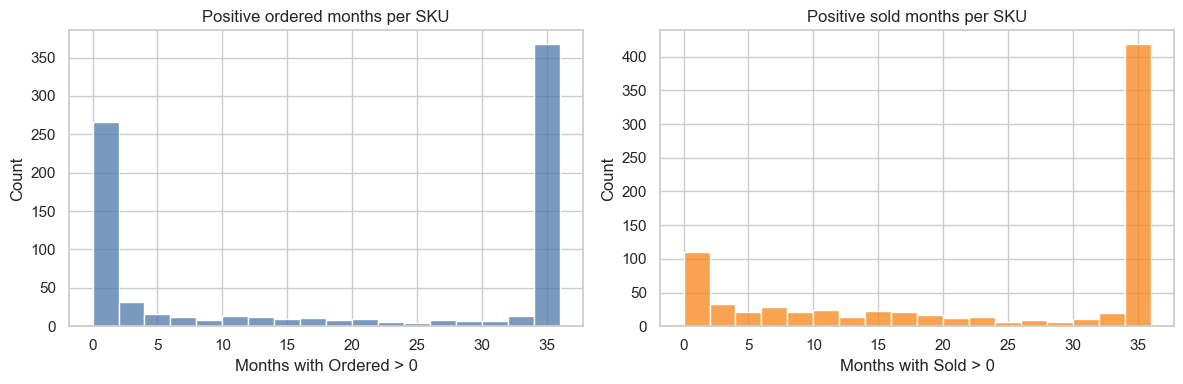

,ordered_positive_months,sold_positive_months
count,809.000000,809.000000
mean,19.464771,23.642769
std,16.540651,14.516709
min,0.000000,0.000000
25%,0.000000,9.000000
50%,25.000000,34.000000
75%,36.000000,36.000000
max,36.000000,36.000000


In [5]:
sku_activity = (
    events_df.groupby("Sku")
    .agg(
        ordered_positive_months=("Ordered", lambda s: s.fillna(0).gt(0).sum()),
        sold_positive_months=("Sold", lambda s: s.fillna(0).gt(0).sum()),
    )
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(sku_activity["ordered_positive_months"], bins=18, ax=axes[0], color="#4C78A8")
axes[0].set_title("Positive ordered months per SKU")
axes[0].set_xlabel("Months with Ordered > 0")

sns.histplot(sku_activity["sold_positive_months"], bins=18, ax=axes[1], color="#F58518")
axes[1].set_title("Positive sold months per SKU")
axes[1].set_xlabel("Months with Sold > 0")

plt.tight_layout()
plt.show()

sku_activity.describe()

The first takeaway is the shape of the panel we are working with. The dataset covers a 36-month period across 809 unique SKUs. Missing SKU-month combinations were filled with zeros during the extraction and initial transformation steps so the panel could be analyzed consistently over time.

That preparation step is important because it gives each SKU the same monthly structure, even when one of the operational signals is absent. At this point, zero values in `Ordered` and `Sold` should not automatically be treated as simple no-demand periods. They need to be interpreted in the context of the business process.

`Ordered` represents store replenishment orders, while `Sold` represents store movement. Because these signals come from different parts of the operation, a zero in one does not necessarily mean zero demand. For example, sales can exist even when there is no recorded order in that period, which may indicate that product was pushed to stores rather than replenished through a standard store order. On the other hand, zero sales can mean there was no movement, or that the product was neither ordered nor pushed into stores during that period.

The SKU activity profile also confirms that the catalog is mixed. Some products show consistent movement across time, while others appear much more sporadically. That already suggests that one single forecasting approach would be too simplistic for the full portfolio.

So after these first checks, the conclusion is not that the demand signal is fully defined. The conclusion is that the panel is structured well enough to move forward, but the relationship between orders and sales still needs to be interpreted carefully. That is what leads into the next step: comparing both signals directly and deciding how to build a target quantity that is usable for forecasting.

## Comparing orders and sales

The first question is what signal should actually be forecasted.

The two main operational signals available are `Ordered` and `Sold`, but neither one is a complete representation of demand on its own. `Ordered` reflects store replenishment behavior, while `Sold` reflects product movement at the store level. Both are useful, but each captures a different part of the process.

From a distribution center operations perspective, forecasting store orders would make the most sense, since that should ideally represent total store demand, including expected sales and other inventory needs such as waste. In practice, though, store orders do not always capture the full picture by themselves.

That distinction matters because the label workflow is tied more closely to expected product flow than to a single transactional measure. A store may sell product without placing a replenishment order in the same period if inventory was already available or if the item was pushed into the store. In the same way, orders may appear ahead of sales if stores are preparing for expected movement. Looking at only one side would miss part of the operational picture.

Because of that, this section compares both signals directly before defining the forecasting target. The goal is to understand how closely they move together, where they diverge, and what those differences say about the process. That comparison will guide the construction of a demand signal that is more useful for planning than either raw field on its own.

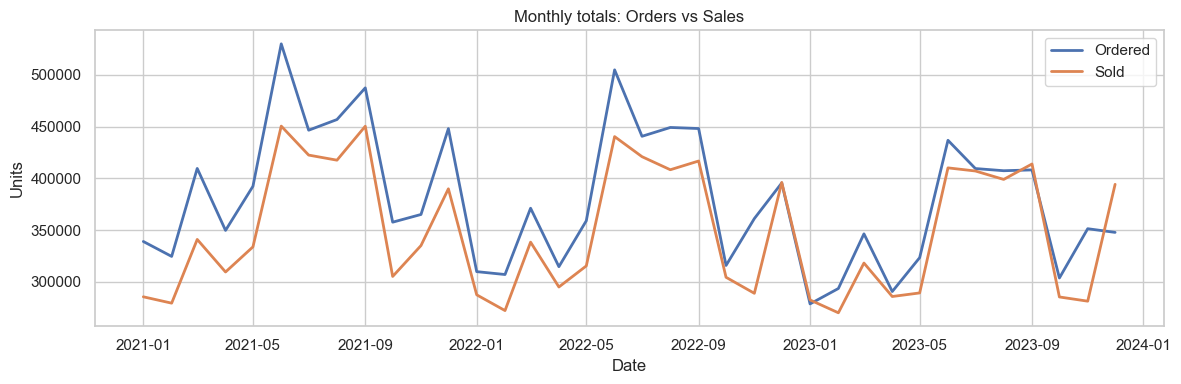

In [6]:
monthly_totals = (
    events_df.groupby("Date")[["Ordered", "Sold"]]
    .sum(min_count=1)
    .reset_index()
)

plt.figure(figsize=(12, 4))
plt.plot(monthly_totals["Date"], monthly_totals["Ordered"], label="Ordered", linewidth=2)
plt.plot(monthly_totals["Date"], monthly_totals["Sold"], label="Sold", linewidth=2)
plt.title("Monthly totals: Orders vs Sales")
plt.xlabel("Date")
plt.ylabel("Units")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
comparison_df = events_df.loc[
    events_df["Ordered"].notna() & events_df["Sold"].notna() & (events_df["Sold"] > 0),
    ["Sku", "Date", "Ordered", "Sold"]
].copy()

comparison_df["pct_error"] = (comparison_df["Ordered"] - comparison_df["Sold"]) / comparison_df["Sold"]
comparison_df["abs_pct_error"] = comparison_df["pct_error"].abs()

comparison_summary = pd.DataFrame(
    {
        "metric": [
            "Rows with both Ordered and Sold",
            "Rows with both positive",
            "Ordered >= Sold",
            "Sold > Ordered",
            "Within 10% gap",
            "Within 25% gap",
            "Median pct error",
            "Mean pct error",
        ],
        "value": [
            len(events_df.loc[events_df["Ordered"].notna() & events_df["Sold"].notna()]),
            len(comparison_df),
            f"{(comparison_df['Ordered'].ge(comparison_df['Sold']).mean() * 100):.2f}%",
            f"{(comparison_df['Sold'].gt(comparison_df['Ordered']).mean() * 100):.2f}%",
            f"{(comparison_df['abs_pct_error'].le(0.10).mean() * 100):.2f}%",
            f"{(comparison_df['abs_pct_error'].le(0.25).mean() * 100):.2f}%",
            f"{(comparison_df['pct_error'].median() * 100):.2f}%",
            f"{(comparison_df['pct_error'].mean() * 100):.2f}%",
        ],
    }
)

comparison_summary

,metric,value
0,Rows with both Ordered and Sold,20376
1,Rows with both positive,16585
2,Ordered >= Sold,76.80%
3,Sold > Ordered,23.20%
4,Within 10% gap,20.86%
5,Within 25% gap,51.63%
6,Median pct error,15.96%
7,Mean pct error,31.14%


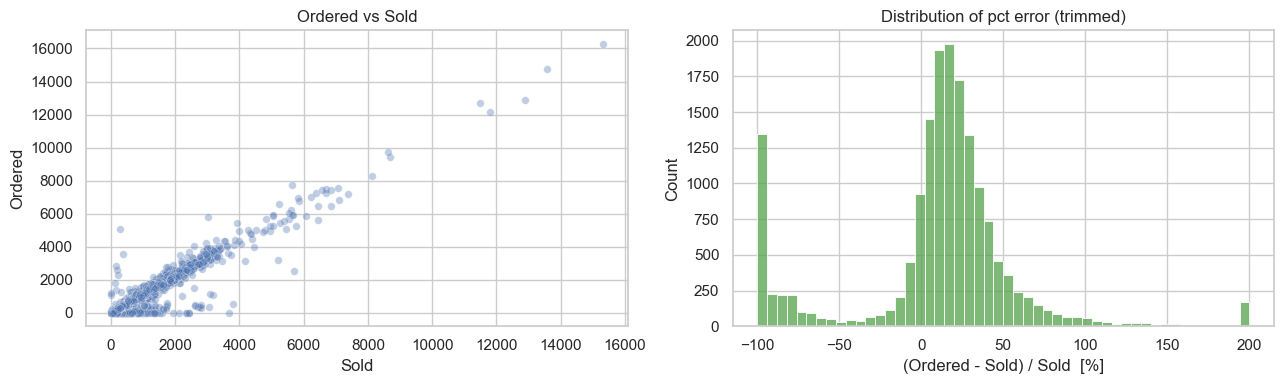

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.scatterplot(
    data=comparison_df.sample(min(len(comparison_df), 4000), random_state=84),
    x="Sold",
    y="Ordered",
    alpha=0.35,
    s=30,
    ax=axes[0]
)
axes[0].set_title("Ordered vs Sold")
axes[0].set_xlabel("Sold")
axes[0].set_ylabel("Ordered")

pct_error_plot = comparison_df["pct_error"] * 100
pct_error_plot = pct_error_plot.clip(
    lower=pct_error_plot.quantile(0.01),
    upper=pct_error_plot.quantile(0.99)
)

sns.histplot(pct_error_plot, bins=50, ax=axes[1], color="#54A24B")
axes[1].set_title("Distribution of pct error (trimmed)")
axes[1].set_xlabel("(Ordered - Sold) / Sold  [%]")

plt.tight_layout()
plt.show()

The comparison shows that `Ordered` and `Sold` are related, but they are not interchangeable.

At the aggregate monthly level, both series move together reasonably well, which suggests they are responding to the same underlying business activity. That is a good sign, because it means both variables contain useful demand information even if they do not match perfectly period by period.

The differences become more meaningful at the SKU-month level. When orders are above sales, that can simply mean stores replenished inventory but did not fully sell through it during the same period. In that case, sales alone may understate the amount of product flow the operation was planning for. On the other hand, when sales are very close to store orders, it raises a different question: was observed movement limited by what was available? If inventory was tight, sales may reflect what could be sold, not necessarily the full level of potential demand.

This is where the main target-definition question appears. `Ordered` is operationally closer to what the distribution center is trying to supply, but it does not always capture the full picture on its own. `Sold` reflects actual movement, but it can also be constrained by inventory availability or timing effects. Neither field by itself gives a complete view of demand.

So the takeaway from this comparison is not that one signal is correct and the other is wrong. The takeaway is that both contain useful information, and the forecasting target needs to be built in a way that better represents the demand signal the label process actually needs.

## Engineering the target quantity

To move into forecasting, a single target quantity needs to be defined at the SKU-month level.

The target used here is built from store orders and store sales using a fallback rule based on observed sell-through behavior.

In [9]:
order_greater_than_sales = events_df.loc[
    events_df["Ordered"] > events_df["Sold"],
    "Sku"
].unique()

sell_through_df = events_df[
    events_df["Sku"].isin(order_greater_than_sales)
].copy()

sell_through_df["sell_through"] = (
    sell_through_df["Sold"] / sell_through_df["Ordered"]
)

weighted_avg_st = (
    (sell_through_df["sell_through"] * sell_through_df["Ordered"]).sum()
    / sell_through_df["Ordered"].sum()
)

fallback_factor = 1 / weighted_avg_st

weighted_avg_st, fallback_factor

(np.float64(0.8628578737419598), np.float64(1.1589394156691128))

In [10]:
events_df["target_qty"] = np.where(
    events_df["Sold"].isna() & events_df["Ordered"].notna(),
    events_df["Ordered"],
    np.where(
        (events_df["Ordered"].notna()) & (events_df["Ordered"] >= fallback_factor * events_df["Sold"]),
        events_df["Ordered"],
        np.ceil(events_df["Sold"].fillna(0) * fallback_factor)
    )
)

events_df["target_source"] = np.where(
    events_df["Sold"].isna() & events_df["Ordered"].notna(),
    "Ordered",
    np.where(
        (events_df["Ordered"].notna()) & (events_df["Ordered"] >= fallback_factor * events_df["Sold"]),
        "Ordered",
        "Estimated"
    )
)

events_df[["Sku", "Date", "Ordered", "Sold", "target_qty", "target_source"]].head(10)

,Sku,Date,Ordered,Sold,target_qty,target_source
0,SKU_0632,2021-01-01,0.0,0.0,0.0,Ordered
1,SKU_0632,2021-02-01,0.0,0.0,0.0,Ordered
2,SKU_0632,2021-03-01,0.0,0.0,0.0,Ordered
3,SKU_0632,2021-04-01,0.0,0.0,0.0,Ordered
4,SKU_0632,2021-05-01,0.0,0.0,0.0,Ordered
5,SKU_0632,2021-06-01,0.0,0.0,0.0,Ordered
6,SKU_0632,2021-07-01,0.0,0.0,0.0,Ordered
7,SKU_0632,2021-08-01,0.0,0.0,0.0,Ordered
8,SKU_0632,2021-09-01,0.0,5.0,6.0,Estimated
9,SKU_0632,2021-10-01,0.0,0.0,0.0,Ordered


In [11]:
target_source_summary = (
    events_df["target_source"]
    .value_counts(normalize=True, dropna=False)
    .rename_axis("target_source")
    .reset_index(name="share")
)

target_source_summary["share"] = (target_source_summary["share"] * 100).round(2)
target_source_summary

,target_source,share
0,Estimated,56.35
1,Ordered,43.65


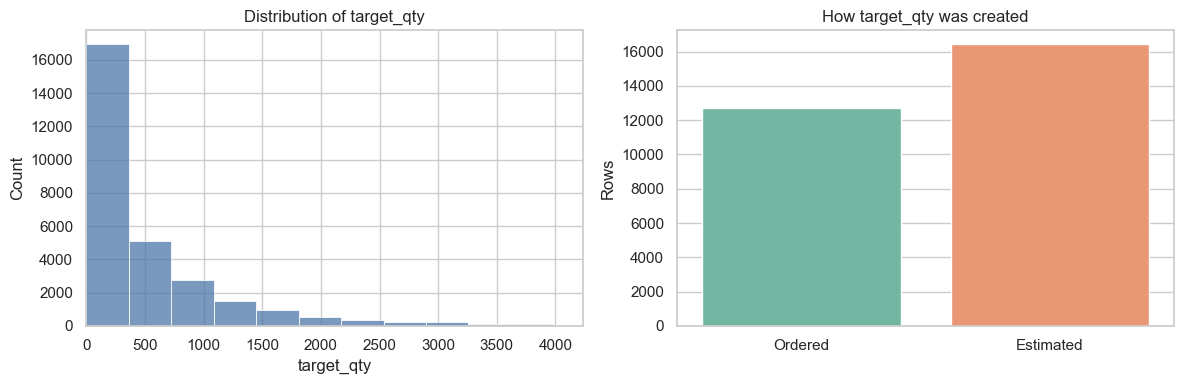

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(events_df["target_qty"], bins=50, ax=axes[0], color="#4C78A8")
axes[0].set_title("Distribution of target_qty")
axes[0].set_xlabel("target_qty")
axes[0].set_xlim(0, events_df["target_qty"].quantile(0.99))

sns.countplot(data=events_df, x="target_source", ax=axes[1], hue="target_source", dodge=False, palette="Set2", legend=False)
axes[1].set_title("How target_qty was created")
axes[1].set_xlabel("")
axes[1].set_ylabel("Rows")

plt.tight_layout()
plt.show()

The target quantity is built to preserve store orders when they look reliable, and to estimate demand from sales when orders appear to understate product flow.

To do that, I first look at the periods where `Ordered > Sold`. Those cases provide a view of normal sell-through when stores replenished more than they ended up moving in the same month. From that subset, I calculate a weighted average sell-through rate and convert it into a fallback factor.

That fallback factor is then used as a simple estimator of implied demand. If store orders are missing, or if they fall below `fallback_factor × Sold`, the target is set by scaling sales up with that factor. Otherwise, the target keeps the observed store order quantity.

This rule keeps the target anchored to store orders when they seem to reflect actual replenishment need, while still protecting against cases where orders may be too low relative to observed movement. The result is not a claim of exact true demand, but a more operationally useful signal for label planning.

## Feature engineering

Now that `target_qty` is defined, the next step is to describe each SKU by its demand behavior.

The goal here is to move from SKU-month observations to SKU-level features that capture how each item behaves over time. These features will be used to separate the catalog into groups with different forecasting needs.

In [13]:
mean_demand_df = (
    events_df.groupby("Sku", as_index=False)["target_qty"]
    .mean()
    .rename(columns={"target_qty": "mean_demand"})
)

std_demand_df = (
    events_df.groupby("Sku", as_index=False)["target_qty"]
    .std()
    .rename(columns={"target_qty": "std_demand"})
)

features_df = mean_demand_df.merge(std_demand_df, on="Sku")
features_df["cv"] = features_df["std_demand"] / features_df["mean_demand"]
features_df["cv"] = features_df["cv"].replace([np.inf, -np.inf], np.nan).fillna(0)

months_per_sku = (
    events_df.groupby("Sku", as_index=False)["target_qty"]
    .count()
    .rename(columns={"target_qty": "total_months"})
)

zero_months = (
    events_df[events_df["target_qty"] == 0]
    .groupby("Sku", as_index=False)["target_qty"]
    .count()
    .rename(columns={"target_qty": "zero_months"})
)

features_df = features_df.merge(months_per_sku, on="Sku")
features_df = features_df.merge(zero_months, on="Sku", how="left")
features_df["zero_months"] = features_df["zero_months"].fillna(0)

features_df["pct_zeros"] = features_df["zero_months"] / features_df["total_months"]
features_df["non_zero_months"] = features_df["total_months"] - features_df["zero_months"]
features_df["adi"] = features_df["total_months"] / features_df["non_zero_months"]
features_df["adi"] = features_df["adi"].replace([np.inf, -np.inf], np.nan)

features_df["cv2"] = features_df["cv"] ** 2
features_df["cv2"] = features_df["cv2"].replace([np.inf, -np.inf], np.nan)

features_df[["Sku", "mean_demand", "std_demand", "cv", "pct_zeros", "adi", "cv2"]].head()

,Sku,mean_demand,std_demand,cv,pct_zeros,adi,cv2
0,SKU_0001,294.083333,53.215129,0.180953,0.000000,1.0,0.032744
1,SKU_0002,0.000000,0.000000,0.000000,1.000000,NaN,0.000000
2,SKU_0003,0.055556,0.333333,6.000000,0.972222,36.0,36.000000
3,SKU_0004,72.611111,176.664861,2.433028,0.750000,4.0,5.919625
4,SKU_0005,2.944444,17.666667,6.000000,0.972222,36.0,36.000000


In [14]:
all_skus = set(events_df["Sku"].unique())
features_df = features_df.dropna().reset_index(drop=True)
valid_skus = set(features_df["Sku"].unique())
dropped_skus = sorted(all_skus - valid_skus)

events_df = events_df[events_df["Sku"].isin(valid_skus)].copy()

cleanup_summary = pd.DataFrame(
    {
        "metric": ["SKUs before cleanup", "SKUs after cleanup", "Dropped SKUs"],
        "value": [len(all_skus), len(valid_skus), len(dropped_skus)],
    }
)

cleanup_summary

,metric,value
0,SKUs before cleanup,809
1,SKUs after cleanup,754
2,Dropped SKUs,55


In [15]:
agg_features = events_df.groupby("Sku")["target_qty"].agg(
    mean_demand="mean",
    max_demand="max",
    p90_demand=lambda x: x.quantile(0.90)
)

agg_features["max_to_mean"] = (
    agg_features["max_demand"] /
    (agg_features["mean_demand"] + 1e-6)
)

cutoff_date_6m = events_df["Date"].max() - pd.DateOffset(months=6)
recent_6m = events_df[events_df["Date"] >= cutoff_date_6m]
recent_features_6m = recent_6m.groupby("Sku")["target_qty"].agg(
    non_zero_count_last_6m=lambda x: (x > 0).sum(),
    mean_demand_last_6m="mean"
)

cutoff_date_12m = events_df["Date"].max() - pd.DateOffset(months=12)
recent_12m = events_df[events_df["Date"] >= cutoff_date_12m]
recent_features_12m = recent_12m.groupby("Sku")["target_qty"].agg(
    non_zero_count_last_12m=lambda x: (x > 0).sum(),
    max_demand_last_12m="max"
)

features_df = (
    features_df.set_index("Sku")
    .join(agg_features[["max_demand", "p90_demand", "max_to_mean"]], how="left")
    .join(recent_features_6m, how="left")
    .join(recent_features_12m, how="left")
    .fillna(0)
    .reset_index()
)

features_df.head()

,Sku,mean_demand,std_demand,cv,total_months,zero_months,pct_zeros,non_zero_months,adi,cv2,max_demand,p90_demand,max_to_mean,non_zero_count_last_6m,mean_demand_last_6m,non_zero_count_last_12m,max_demand_last_12m
0,SKU_0001,294.083333,53.215129,0.180953,36,0.0,0.000000,36.0,1.0,0.032744,399.0,381.5,1.356758,7,292.428571,13,323.0
1,SKU_0003,0.055556,0.333333,6.000000,36,35.0,0.972222,1.0,36.0,36.000000,2.0,0.0,35.999352,1,0.285714,1,2.0
2,SKU_0004,72.611111,176.664861,2.433028,36,27.0,0.750000,9.0,4.0,5.919625,638.0,289.5,8.786534,2,30.571429,3,550.0
3,SKU_0005,2.944444,17.666667,6.000000,36,35.0,0.972222,1.0,36.0,36.000000,106.0,0.0,35.999988,1,15.142857,1,106.0
4,SKU_0006,34.111111,126.970138,3.722252,36,32.0,0.888889,4.0,9.0,13.855157,562.0,5.5,16.475570,0,0.000000,0,0.0


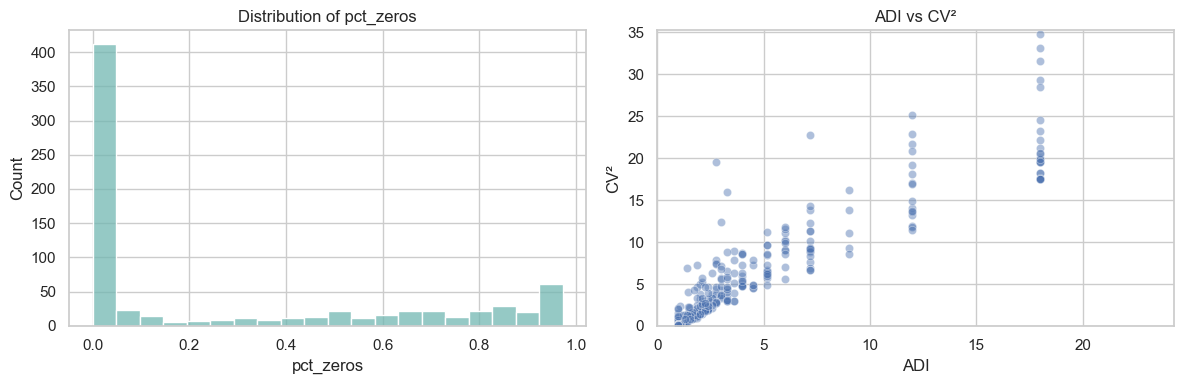

,mean_demand,cv,pct_zeros,adi,max_demand,p90_demand,non_zero_count_last_6m,mean_demand_last_6m,non_zero_count_last_12m,max_demand_last_12m
count,754.00,754.00,754.00,754.00,754.00,754.00,754.00,754.00,754.00,754.00
mean,572.89,1.33,0.28,4.22,1113.19,861.88,5.09,595.43,9.41,948.50
std,881.84,1.60,0.36,8.10,1524.60,1288.76,2.67,920.37,4.87,1376.68
min,0.03,0.12,0.00,1.00,1.00,0.00,0.00,0.00,0.00,0.00
25%,23.75,0.25,0.00,1.00,143.75,44.25,3.00,15.82,5.00,64.50
50%,294.62,0.50,0.00,1.00,667.00,482.50,7.00,309.64,13.00,550.00
75%,770.56,1.92,0.64,2.77,1448.75,1138.88,7.00,801.18,13.00,1245.25
max,11449.83,6.00,0.97,36.00,18100.00,16219.50,7.00,11847.00,13.00,16712.00


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.histplot(features_df["pct_zeros"], bins=20, ax=axes[0], color="#72B7B2")
axes[0].set_title("Distribution of pct_zeros")
axes[0].set_xlabel("pct_zeros")

sns.scatterplot(data=features_df, x="adi", y="cv2", alpha=0.45, s=35, ax=axes[1])
axes[1].set_title("ADI vs CV²")
axes[1].set_xlabel("ADI")
axes[1].set_ylabel("CV²")
axes[1].set_xlim(0, features_df["adi"].quantile(0.95))
axes[1].set_ylim(0, features_df["cv2"].quantile(0.95))

plt.tight_layout()
plt.show()

features_df[[
    "mean_demand", "cv", "pct_zeros", "adi", "max_demand", "p90_demand",
    "non_zero_count_last_6m", "mean_demand_last_6m", "non_zero_count_last_12m", "max_demand_last_12m"
]].describe().round(2)

The dataset now starts to look less like raw history and more like a forecasting problem.

At this point, each SKU has a set of features that summarize how it behaves over time: how much it moves, how variable it is, and how often demand drops to zero. The most important features here are `pct_zeros`, `adi`, and `cv2`, because they help distinguish steady demand from intermittent or highly erratic demand.

That matters because the catalog is not uniform. Some SKUs show a regular monthly pattern, while others move irregularly or stay inactive for long stretches. Before choosing forecasting methods, I need a way to separate those behaviors in a structured way.

## Segmenting the catalog
At this point, using one forecasting approach for every SKU would be forcing the data into something it is not. The behavior is too mixed. Before modeling, I want to separate the catalog into groups that actually behave differently.

In [17]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

clustering_feature_cols = [
    "mean_demand",
    "cv",
    "adi",
    "cv2",
    "pct_zeros",
    "max_demand",
    "p90_demand",
    "max_to_mean",
    "non_zero_count_last_6m",
    "mean_demand_last_6m",
]

clustering_features = features_df.set_index("Sku")[clustering_feature_cols].copy()

scaler = StandardScaler()
scaled_features = scaler.fit_transform(clustering_features)
scaled_df = pd.DataFrame(scaled_features, columns=clustering_feature_cols, index=clustering_features.index)

clustering_features.head()

,mean_demand,cv,adi,cv2,pct_zeros,max_demand,p90_demand,max_to_mean,non_zero_count_last_6m,mean_demand_last_6m
Sku,,,,,,,,,,
SKU_0001,294.083333,0.180953,1.0,0.032744,0.000000,399.0,381.5,1.356758,7,292.428571
SKU_0003,0.055556,6.000000,36.0,36.000000,0.972222,2.0,0.0,35.999352,1,0.285714
SKU_0004,72.611111,2.433028,4.0,5.919625,0.750000,638.0,289.5,8.786534,2,30.571429
SKU_0005,2.944444,6.000000,36.0,36.000000,0.972222,106.0,0.0,35.999988,1,15.142857
SKU_0006,34.111111,3.722252,9.0,13.855157,0.888889,562.0,5.5,16.475570,0,0.000000


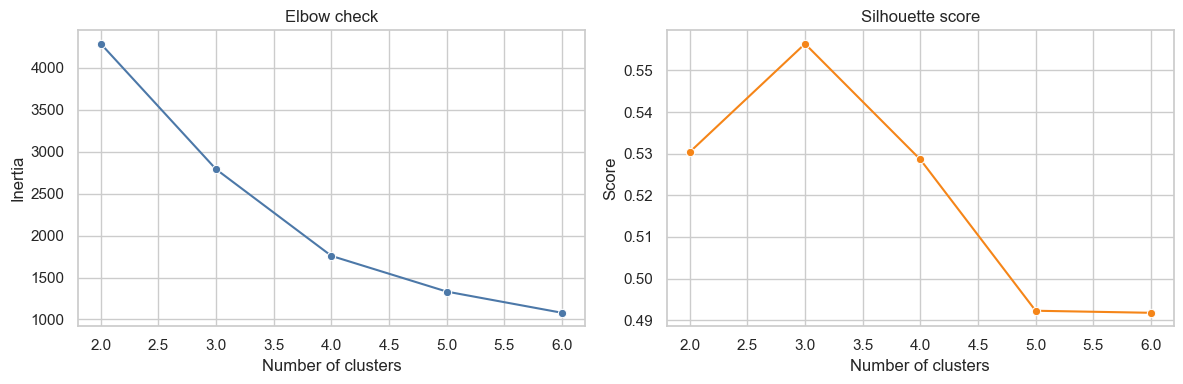

,k,inertia,silhouette_score
0,2,4285.8821,0.5304
1,3,2789.8588,0.5564
2,4,1757.4666,0.5286
3,5,1332.2930,0.4923
4,6,1079.5273,0.4918


In [18]:
inertias = []
silhouette_scores = []
k_range = range(2, 7)

for k in k_range:
    model = KMeans(n_clusters=k, random_state=84, n_init=10)
    labels = model.fit_predict(scaled_df)
    inertias.append(model.inertia_)
    silhouette_scores.append(silhouette_score(scaled_df, labels))

cluster_eval_df = pd.DataFrame(
    {
        "k": list(k_range),
        "inertia": inertias,
        "silhouette_score": silhouette_scores,
    }
)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.lineplot(data=cluster_eval_df, x="k", y="inertia", marker="o", ax=axes[0], color="#4C78A8")
axes[0].set_title("Elbow check")
axes[0].set_xlabel("Number of clusters")
axes[0].set_ylabel("Inertia")

sns.lineplot(data=cluster_eval_df, x="k", y="silhouette_score", marker="o", ax=axes[1], color="#F58518")
axes[1].set_title("Silhouette score")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("Score")

plt.tight_layout()
plt.show()

cluster_eval_df.round(4)

I am not looking for some magical perfect cluster score here. I just want a split that is stable, interpretable, and useful for forecasting. Three clusters gives me the cleanest tradeoff in this dataset, and more importantly, the groups make sense when I look back at the demand behavior.

In [19]:
k_final = 3

kmeans = KMeans(n_clusters=k_final, random_state=84, n_init=10)
cluster_id = kmeans.fit_predict(scaled_df)

features_with_cluster = features_df.copy()
features_with_cluster["cluster_id"] = cluster_id

cluster_profile = (
    features_with_cluster.groupby("cluster_id")[["mean_demand", "pct_zeros", "adi"]]
    .median()
)

intermittent_cluster = cluster_profile["pct_zeros"].idxmax()
remaining_clusters = [c for c in cluster_profile.index if c != intermittent_cluster]
steady_high_cluster = cluster_profile.loc[remaining_clusters, "mean_demand"].idxmax()
steady_mid_cluster = [c for c in remaining_clusters if c != steady_high_cluster][0]

cluster_labels = {
    steady_high_cluster: "Steady High Movers",
    steady_mid_cluster: "Steady Mid Movers",
    intermittent_cluster: "Intermittent / Near-Dead SKUs",
}

features_with_cluster["cluster_label"] = features_with_cluster["cluster_id"].map(cluster_labels)

cluster_label_order = [
    "Steady High Movers",
    "Steady Mid Movers",
    "Intermittent / Near-Dead SKUs",
]

cluster_summary = (
    features_with_cluster.groupby(["cluster_id", "cluster_label"])
    .agg(
        sku_count=("Sku", "nunique"),
        mean_demand=("mean_demand", "median"),
        pct_zeros=("pct_zeros", "median"),
        adi=("adi", "median"),
        cv2=("cv2", "median"),
        max_demand=("max_demand", "median"),
        mean_demand_last_6m=("mean_demand_last_6m", "median"),
        non_zero_count_last_6m=("non_zero_count_last_6m", "median"),
    )
    .reset_index()
)

cluster_summary["cluster_label"] = pd.Categorical(
    cluster_summary["cluster_label"],
    categories=cluster_label_order,
    ordered=True,
)

cluster_summary = cluster_summary.sort_values("cluster_label").reset_index(drop=True)
cluster_summary.round(2)

,cluster_id,cluster_label,sku_count,mean_demand,pct_zeros,adi,cv2,max_demand,mean_demand_last_6m,non_zero_count_last_6m
0,0,Steady High Movers,46,2704.44,0.00,1.0,0.10,4743.0,2902.86,7.0
1,1,Steady Mid Movers,547,411.53,0.00,1.0,0.12,814.0,415.29,7.0
2,2,Intermittent / Near-Dead SKUs,161,2.31,0.89,9.0,13.26,49.0,0.00,0.0


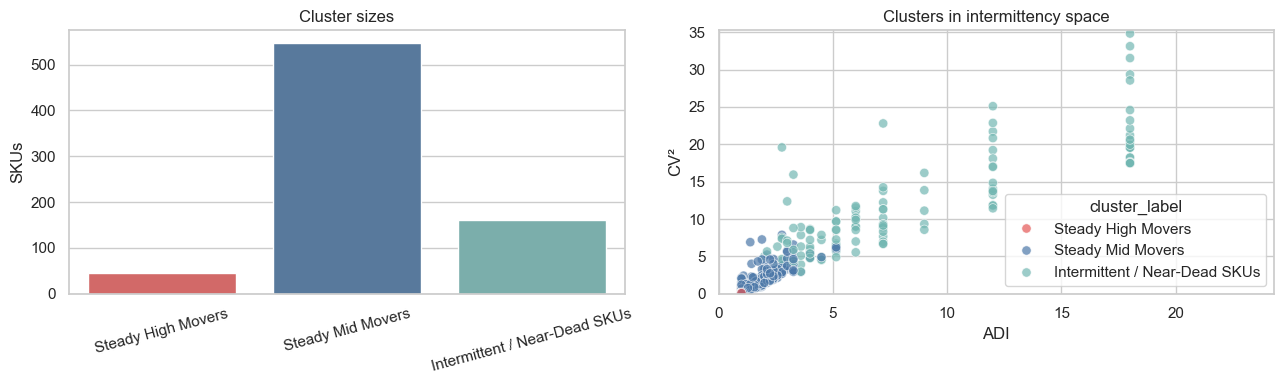

In [20]:
cluster_palette = {
    "Steady High Movers": "#E45756",
    "Steady Mid Movers": "#4C78A8",
    "Intermittent / Near-Dead SKUs": "#72B7B2",
}

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=cluster_summary,
    x="cluster_label",
    y="sku_count",
    order=cluster_label_order,
    hue="cluster_label",
    palette=cluster_palette,
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Cluster sizes")
axes[0].set_xlabel("")
axes[0].set_ylabel("SKUs")
axes[0].tick_params(axis="x", rotation=15)

sns.scatterplot(
    data=features_with_cluster,
    x="adi",
    y="cv2",
    hue="cluster_label",
    hue_order=cluster_label_order,
    palette=cluster_palette,
    alpha=0.7,
    s=45,
    ax=axes[1],
)
axes[1].set_title("Clusters in intermittency space")
axes[1].set_xlabel("ADI")
axes[1].set_ylabel("CV²")
axes[1].set_xlim(0, features_with_cluster["adi"].quantile(0.95))
axes[1].set_ylim(0, features_with_cluster["cv2"].quantile(0.95))

plt.tight_layout()
plt.show()

This split is useful right away. One cluster is made of steady high movers, one is steady but more moderate, and one is mostly intermittent or close to dead. That matches what I was seeing earlier when I looked at zeros, ADI, and volatility.

That is important because I do not want to forecast these groups the same way. The steady movers can support a richer time-series model. The intermittent group needs something more conservative. So the clustering step is not just descriptive. It is the bridge between EDA and model choice.

## Validating models for the steady movers
The steady clusters are the first place where I expect a regular time-series model to actually have an edge. But I still do not want to assume that. I want to compare ETS against a very plain benchmark first and see if the extra complexity is really buying something.

In [21]:
import warnings

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tools.sm_exceptions import ConvergenceWarning

warnings.filterwarnings("ignore", category=ConvergenceWarning)

events_with_cluster = events_df.merge(
    features_with_cluster[["Sku", "cluster_id", "cluster_label"]],
    on="Sku",
    how="left",
)

steady_labels = ["Steady High Movers", "Steady Mid Movers"]
steady_skus = features_with_cluster.loc[
    features_with_cluster["cluster_label"].isin(steady_labels),
    "Sku",
].unique()

forecast_horizon = 3
seasonal_periods = 12
min_train_points = 24
test_dates = pd.to_datetime(sorted(events_with_cluster["Date"].unique())[-forecast_horizon:])
test_start = test_dates.min()
test_end = test_dates.max()

validation_setup = pd.DataFrame(
    {
        "metric": [
            "Steady-mover SKUs",
            "Forecast horizon",
            "Train end",
            "Validation start",
            "Validation end",
        ],
        "value": [
            len(steady_skus),
            f"{forecast_horizon} months",
            (test_start - pd.DateOffset(days=1)).date(),
            test_start.date(),
            test_end.date(),
        ],
    }
)

validation_setup

,metric,value
0,Steady-mover SKUs,593
1,Forecast horizon,3 months
2,Train end,2023-09-30
3,Validation start,2023-10-01
4,Validation end,2023-12-01


In [22]:
def compute_metrics(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    err = y_true - y_pred

    mae = float(np.mean(np.abs(err)))
    rmse = float(np.sqrt(np.mean(err ** 2)))
    mape = float(np.mean(np.abs(err) / np.maximum(y_true, 1)) * 100)
    bias = float(np.mean(y_pred - y_true))

    denom = float(np.sum(y_true))
    wape = float(np.sum(np.abs(err)) / denom * 100) if denom > 0 else np.nan

    smape_denom = np.abs(y_true) + np.abs(y_pred)
    mask = smape_denom > 0
    smape = float(
        np.mean(2 * np.abs(err[mask]) / smape_denom[mask]) * 100
        if mask.any() else 0.0
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "MAPE": mape,
        "WAPE": wape,
        "sMAPE": smape,
        "Bias": bias,
    }


def summarise_eval(eval_df, group_cols):
    rows = []
    for group_key, grp in eval_df.groupby(group_cols, dropna=False):
        if not isinstance(group_key, tuple):
            group_key = (group_key,)

        row = {col: value for col, value in zip(group_cols, group_key)}
        row["n_skus"] = grp["Sku"].nunique()
        row.update(compute_metrics(grp["Actual"], grp["Forecast"]))
        rows.append(row)

    return pd.DataFrame(rows)


In [23]:
steady_eval_rows = []

for sku in steady_skus:
    ts = events_with_cluster.loc[
        events_with_cluster["Sku"] == sku,
        ["Date", "target_qty", "cluster_label"],
    ].sort_values("Date").copy()

    train = ts[ts["Date"] < test_start]
    test = ts[ts["Date"].isin(test_dates)].sort_values("Date")

    if len(train) < min_train_points or len(test) != forecast_horizon:
        continue

    history = ts.set_index("Date")["target_qty"]
    seasonal_naive_forecast = []
    seasonal_naive_ok = True

    for dt in test["Date"]:
        reference_date = dt - pd.DateOffset(months=seasonal_periods)
        if reference_date not in history.index:
            seasonal_naive_ok = False
            break
        seasonal_naive_forecast.append(float(history.loc[reference_date]))

    if seasonal_naive_ok:
        for dt, actual, pred, cluster_label in zip(
            test["Date"],
            test["target_qty"],
            seasonal_naive_forecast,
            test["cluster_label"],
        ):
            steady_eval_rows.append(
                {
                    "Sku": sku,
                    "Date": dt,
                    "Actual": float(actual),
                    "Forecast": float(max(pred, 0)),
                    "Model": "Seasonal Naive",
                    "cluster_label": cluster_label,
                }
            )

    try:
        ets_model = ExponentialSmoothing(
            train["target_qty"].to_numpy(),
            trend="add",
            seasonal="add",
            damped_trend=True,
            seasonal_periods=seasonal_periods,
            initialization_method="estimated",
        ).fit()

        ets_forecast = np.clip(
            np.asarray(ets_model.forecast(forecast_horizon), dtype=float),
            0,
            None,
        )

        for dt, actual, pred, cluster_label in zip(
            test["Date"],
            test["target_qty"],
            ets_forecast,
            test["cluster_label"],
        ):
            steady_eval_rows.append(
                {
                    "Sku": sku,
                    "Date": dt,
                    "Actual": float(actual),
                    "Forecast": float(pred),
                    "Model": "ETS",
                    "cluster_label": cluster_label,
                }
            )
    except Exception:
        continue

steady_eval_df = pd.DataFrame(steady_eval_rows)

model_summary = summarise_eval(steady_eval_df, ["Model"])
cohort_summary = summarise_eval(steady_eval_df, ["Model", "cluster_label"])

model_summary.round(2)

,Model,n_skus,MAE,RMSE,MAPE,WAPE,sMAPE,Bias
0,ETS,593,120.05,231.77,791.27,18.20,40.26,2.79
1,Seasonal Naive,593,128.05,280.70,2160.11,19.41,37.15,24.94


In [24]:
cohort_summary["cluster_label"] = pd.Categorical(
    cohort_summary["cluster_label"],
    categories=cluster_label_order,
    ordered=True,
)

cohort_summary = cohort_summary.sort_values(["cluster_label", "Model"]).reset_index(drop=True)
cohort_summary.round(2)

,Model,cluster_label,n_skus,MAE,RMSE,MAPE,WAPE,sMAPE,Bias
0,ETS,Steady High Movers,46,371.34,555.21,14.95,13.56,17.29,8.99
1,Seasonal Naive,Steady High Movers,46,467.70,757.12,6349.74,17.08,19.64,146.17
2,ETS,Steady Mid Movers,547,98.92,179.76,856.56,20.40,42.30,2.26
3,Seasonal Naive,Steady Mid Movers,547,99.48,192.91,1807.78,20.51,38.76,14.75


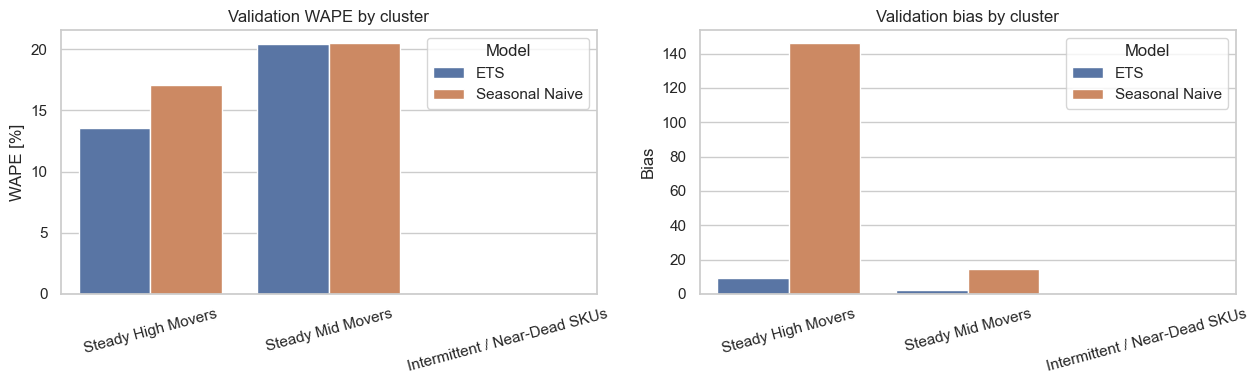

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=cohort_summary,
    x="cluster_label",
    y="WAPE",
    hue="Model",
    order=cluster_label_order,
    ax=axes[0],
)
axes[0].set_title("Validation WAPE by cluster")
axes[0].set_xlabel("")
axes[0].set_ylabel("WAPE [%]")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    data=cohort_summary,
    x="cluster_label",
    y="Bias",
    hue="Model",
    order=cluster_label_order,
    ax=axes[1],
)
axes[1].set_title("Validation bias by cluster")
axes[1].set_xlabel("")
axes[1].set_ylabel("Bias")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

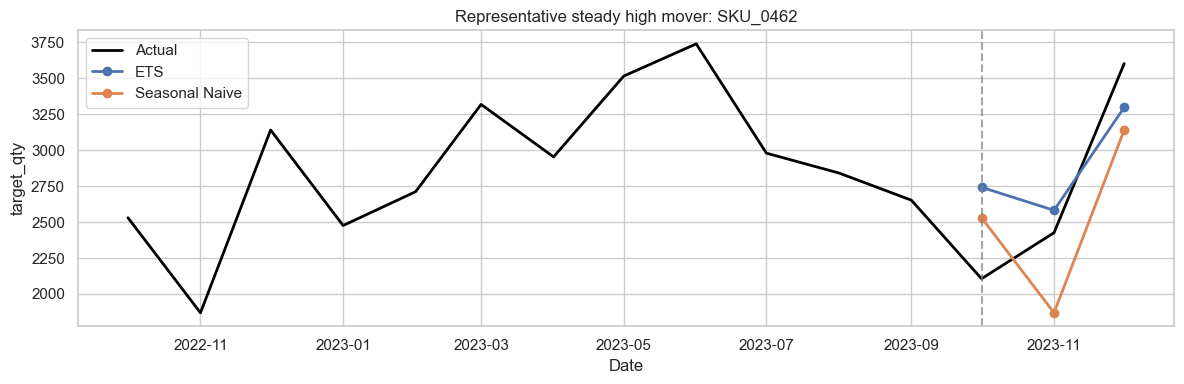

In [26]:
sample_pool = features_with_cluster.loc[
    features_with_cluster["cluster_label"] == "Steady High Movers"
].copy()
sample_target = sample_pool["mean_demand"].median()
sample_sku = sample_pool.iloc[(sample_pool["mean_demand"] - sample_target).abs().argsort()].iloc[0]["Sku"]

sample_history = events_with_cluster.loc[
    events_with_cluster["Sku"] == sample_sku,
    ["Date", "target_qty"],
].sort_values("Date")

sample_eval = steady_eval_df.loc[steady_eval_df["Sku"] == sample_sku].sort_values(["Model", "Date"])
plot_start = test_start - pd.DateOffset(months=12)

plt.figure(figsize=(12, 4))
plt.plot(
    sample_history.loc[sample_history["Date"] >= plot_start, "Date"],
    sample_history.loc[sample_history["Date"] >= plot_start, "target_qty"],
    label="Actual",
    linewidth=2,
    color="black",
)

for model_name, grp in sample_eval.groupby("Model"):
    plt.plot(grp["Date"], grp["Forecast"], marker="o", linewidth=2, label=model_name)

plt.axvline(test_start, color="gray", linestyle="--", alpha=0.7)
plt.title(f"Representative steady high mover: {sample_sku}")
plt.xlabel("Date")
plt.ylabel("target_qty")
plt.legend()
plt.tight_layout()
plt.show()

This is enough for me to justify the split.

ETS is not perfect, but it does beat a simple seasonal-naive benchmark on the steady movers, and the edge is clearer in the high-volume group. That is the main point here. I am not trying to prove ETS is the best model overall, only that for the more stable SKUs, a regular time-series model starts to add value over a very basic baseline.

For this project, WAPE, RMSE, and bias are more useful because they stay closer to the business scale and give a more practical view of forecast quality.

So at this point the decision feels clear enough. The steady movers can be forecasted with ETS, while the intermittent and near-dead SKUs need a different forecasting logic.

## Validating models for the intermittent cluster
This cluster is a different problem. A lot of these SKUs disappear for long stretches, so a smooth seasonal model is not the right tool anymore. Here I want to compare a very conservative baseline against intermittent-demand methods and see which one gives the most usable signal.

In [27]:
def get_monthly_series(events_df, sku, date_col="Date", y_col="target_qty"):
    ts = (
        events_df[events_df["Sku"] == sku]
        .sort_values(date_col)
        .set_index(date_col)[y_col]
        .asfreq("MS")
        .fillna(0.0)
    )
    return ts


def croston_sba(y, alpha=0.1, h=1):
    y = np.asarray(y, dtype=float)
    n = len(y)

    if n == 0:
        return np.zeros(h)

    demand = y[y > 0]
    if len(demand) == 0:
        return np.zeros(h)

    q = demand[0]
    p = 1.0
    last_demand_idx = np.where(y > 0)[0][0]

    for t in range(last_demand_idx + 1, n):
        if y[t] > 0:
            interval = t - last_demand_idx
            q = q + alpha * (y[t] - q)
            p = p + alpha * (interval - p)
            last_demand_idx = t

    forecast = (1 - alpha / 2) * (q / max(p, 1e-9))
    return np.full(h, max(0.0, forecast))


def tsb(y, alpha=0.1, beta=0.1, h=1):
    y = np.asarray(y, dtype=float)
    n = len(y)

    if n == 0:
        return np.zeros(h)

    first_pos = np.where(y > 0)[0]
    if len(first_pos) == 0:
        return np.zeros(h)

    p = 1.0
    z = y[first_pos[0]]

    for t in range(first_pos[0] + 1, n):
        x = 1.0 if y[t] > 0 else 0.0
        p = p + beta * (x - p)
        if y[t] > 0:
            z = z + alpha * (y[t] - z)

    forecast = p * z
    return np.full(h, max(0.0, forecast))


In [28]:
intermittent_skus = features_with_cluster.loc[
    features_with_cluster["cluster_label"] == "Intermittent / Near-Dead SKUs",
    "Sku",
].unique()

intermittent_horizon = 1
intermittent_test_dates = pd.to_datetime(sorted(events_with_cluster["Date"].unique())[-intermittent_horizon:])
intermittent_test_start = intermittent_test_dates.min()

intermittent_validation_setup = pd.DataFrame(
    {
        "metric": [
            "Intermittent SKUs",
            "Forecast horizon",
            "Train end",
            "Validation month",
        ],
        "value": [
            len(intermittent_skus),
            f"{intermittent_horizon} month",
            (intermittent_test_start - pd.DateOffset(days=1)).date(),
            intermittent_test_start.date(),
        ],
    }
)

intermittent_validation_setup

,metric,value
0,Intermittent SKUs,161
1,Forecast horizon,1 month
2,Train end,2023-11-30
3,Validation month,2023-12-01


In [29]:
intermittent_eval_rows = []

for sku in intermittent_skus:
    ts = get_monthly_series(events_with_cluster, sku)
    train = ts[ts.index < intermittent_test_start]
    test = ts[ts.index.isin(intermittent_test_dates)]

    if len(train) < 24 or len(test) != intermittent_horizon:
        continue

    model_forecasts = {
        "Zero Forecast": np.zeros(intermittent_horizon, dtype=float),
        "Croston SBA": croston_sba(train.to_numpy(), alpha=0.1, h=intermittent_horizon),
        "TSB": tsb(train.to_numpy(), alpha=0.1, beta=0.1, h=intermittent_horizon),
    }

    for model_name, forecast_values in model_forecasts.items():
        forecast_values = np.clip(np.asarray(forecast_values, dtype=float), 0, None)

        for dt, actual, pred in zip(test.index, test.to_numpy(), forecast_values):
            intermittent_eval_rows.append(
                {
                    "Sku": sku,
                    "Date": dt,
                    "Actual": float(actual),
                    "Forecast": float(pred),
                    "Model": model_name,
                }
            )

intermittent_eval_df = pd.DataFrame(intermittent_eval_rows)
intermittent_model_summary = summarise_eval(intermittent_eval_df, ["Model"]).sort_values("WAPE").reset_index(drop=True)

intermittent_model_summary.round(2)

,Model,n_skus,MAE,RMSE,MAPE,WAPE,sMAPE,Bias
0,Zero Forecast,161,58.64,229.90,38.51,100.00,200.00,-58.64
1,TSB,161,61.45,205.26,1101.88,104.80,177.29,-31.38
2,Croston SBA,161,74.96,204.78,2599.65,127.83,173.04,-12.48


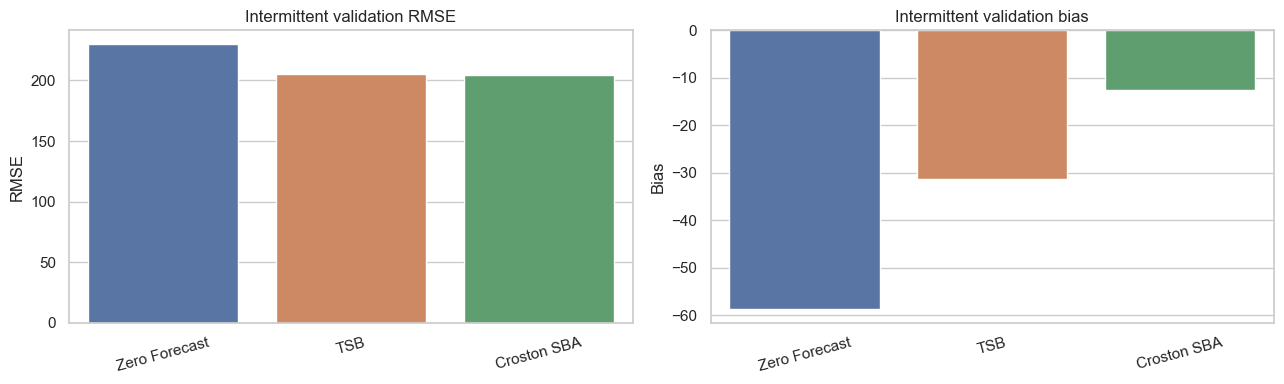

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.barplot(
    data=intermittent_model_summary,
    x="Model",
    y="RMSE",
    hue="Model",
    dodge=False,
    legend=False,
    ax=axes[0],
)
axes[0].set_title("Intermittent validation RMSE")
axes[0].set_xlabel("")
axes[0].set_ylabel("RMSE")
axes[0].tick_params(axis="x", rotation=15)

sns.barplot(
    data=intermittent_model_summary,
    x="Model",
    y="Bias",
    hue="Model",
    dodge=False,
    legend=False,
    ax=axes[1],
)
axes[1].set_title("Intermittent validation bias")
axes[1].set_xlabel("")
axes[1].set_ylabel("Bias")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

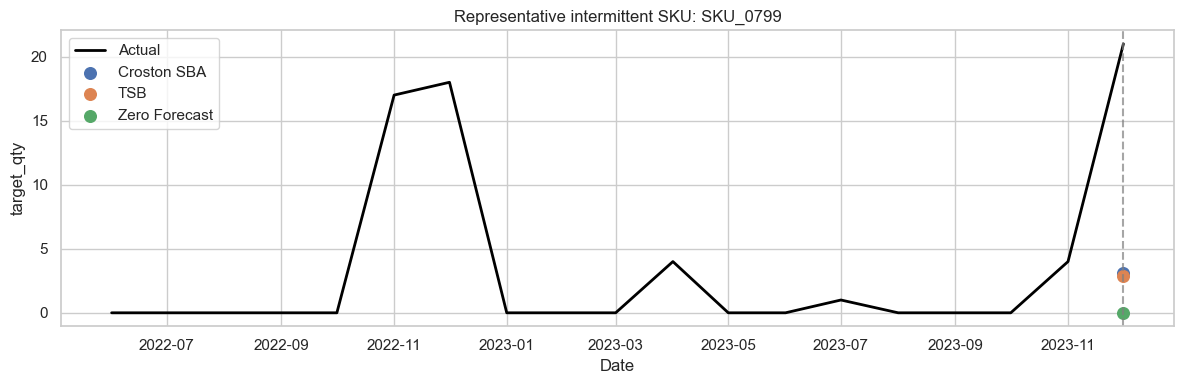

In [31]:
positive_holdout_pool = intermittent_eval_df.loc[
    (intermittent_eval_df["Actual"] > 0) & (intermittent_eval_df["Model"] == "TSB")
].copy()

positive_target = positive_holdout_pool["Actual"].median()
intermittent_sample_sku = positive_holdout_pool.iloc[
    (positive_holdout_pool["Actual"] - positive_target).abs().argsort()
].iloc[0]["Sku"]

intermittent_sample_history = events_with_cluster.loc[
    events_with_cluster["Sku"] == intermittent_sample_sku,
    ["Date", "target_qty"],
].sort_values("Date")

intermittent_sample_eval = intermittent_eval_df.loc[
    intermittent_eval_df["Sku"] == intermittent_sample_sku
].sort_values(["Model", "Date"])

intermittent_plot_start = intermittent_test_start - pd.DateOffset(months=18)

plt.figure(figsize=(12, 4))
plt.plot(
    intermittent_sample_history.loc[
        intermittent_sample_history["Date"] >= intermittent_plot_start,
        "Date",
    ],
    intermittent_sample_history.loc[
        intermittent_sample_history["Date"] >= intermittent_plot_start,
        "target_qty",
    ],
    label="Actual",
    linewidth=2,
    color="black",
)

for model_name, grp in intermittent_sample_eval.groupby("Model"):
    plt.scatter(grp["Date"], grp["Forecast"], s=70, label=model_name)

plt.axvline(intermittent_test_start, color="gray", linestyle="--", alpha=0.7)
plt.title(f"Representative intermittent SKU: {intermittent_sample_sku}")
plt.xlabel("Date")
plt.ylabel("target_qty")
plt.legend()
plt.tight_layout()
plt.show()

This part is a little more nuanced, and I think that is actually important to show. If I only optimize for WAPE, the zero forecast looks strong, which makes sense because this cluster spends so much time at zero.

But that is also the problem. A zero forecast is basically a passive answer. It works on paper because it misses quietly. TSB gives me a more useful planning signal. In this validation it brings RMSE down versus the zero baseline and cuts the underforecast bias a lot, while Croston SBA tends to be more error-prone overall.

So I would not call this a clean win on every metric. I would call it the better operational choice. For the sparse items, I want a method that still respects intermittency without pretending the safest answer is always zero.

## Turning forecasts into decisions
At this point I have enough to stop talking about models in isolation and turn them into something operational. For the steady movers, I use the buffered ETS forecast as the action quantity. For the intermittent group, I treat the TSB signal more carefully and convert it into a standing inventory rule instead of pretending I have a clean monthly pattern.

In [32]:
future_horizon = 12
future_start = events_with_cluster["Date"].max() + pd.DateOffset(months=1)
future_dates = pd.date_range(start=future_start, periods=future_horizon, freq="MS")

decision_setup = pd.DataFrame(
    {
        "metric": [
            "Planning horizon",
            "Start month",
            "End month",
            "Steady mover SKUs",
            "Intermittent SKUs",
        ],
        "value": [
            f"{future_horizon} months",
            future_dates.min().date(),
            future_dates.max().date(),
            len(steady_skus),
            len(intermittent_skus),
        ],
    }
)

decision_setup

,metric,value
0,Planning horizon,12 months
1,Start month,2024-01-01
2,End month,2024-12-01
3,Steady mover SKUs,593
4,Intermittent SKUs,161


In [33]:
upper_alpha = 0.90
steady_plan_rows = []

for sku in steady_skus:
    ts = events_with_cluster.loc[
        events_with_cluster["Sku"] == sku,
        ["Date", "target_qty", "cluster_label"],
    ].sort_values("Date")

    if len(ts) < 24:
        continue

    try:
        steady_model = ExponentialSmoothing(
            ts["target_qty"].to_numpy(),
            trend="add",
            seasonal="add",
            damped_trend=True,
            seasonal_periods=12,
            initialization_method="estimated",
        ).fit()

        point_forecast = np.clip(
            np.asarray(steady_model.forecast(len(future_dates)), dtype=float),
            0,
            None,
        )

        resid = np.asarray(steady_model.resid, dtype=float)
        pos_resid = resid[resid > 0]
        buffer = float(np.quantile(pos_resid, upper_alpha)) if len(pos_resid) > 0 else 0.0
        upper_forecast = np.clip(point_forecast + buffer, 0, None)

        cluster_label = ts["cluster_label"].iloc[0]

        for dt, forecast_value, upper_value in zip(future_dates, point_forecast, upper_forecast):
            steady_plan_rows.append(
                {
                    "Sku": sku,
                    "Date": dt,
                    "cluster_label": cluster_label,
                    "Model": "ETS",
                    "Forecast": float(forecast_value),
                    "Forecast_Buffer": float(np.ceil(upper_value)),
                    "Inventory": int(np.ceil(upper_value)),
                    "Decision": "Buffered_ETS",
                }
            )
    except Exception:
        continue

steady_inventory_plan = pd.DataFrame(steady_plan_rows)
steady_inventory_plan.head()

,Sku,Date,cluster_label,Model,Forecast,Forecast_Buffer,Inventory,Decision
0,SKU_0001,2024-01-01,Steady Mid Movers,ETS,180.507211,226.0,226,Buffered_ETS
1,SKU_0001,2024-02-01,Steady Mid Movers,ETS,217.211926,263.0,263,Buffered_ETS
2,SKU_0001,2024-03-01,Steady Mid Movers,ETS,258.937636,305.0,305,Buffered_ETS
3,SKU_0001,2024-04-01,Steady Mid Movers,ETS,203.684812,250.0,250,Buffered_ETS
4,SKU_0001,2024-05-01,Steady Mid Movers,ETS,226.238207,272.0,272,Buffered_ETS


For the intermittent SKUs, I am not using TSB as a direct month-by-month forecast in the same way as ETS.

The TSB output is treated as a demand signal. If that signal is very weak, the SKU drops to no inventory. If it remains active, I compare the forecast against the maximum observed demand in the last 12 months and set inventory using the more protective of the two, with an additional 20% buffer on the recent peak.

This is intentionally conservative. Intermittent demand does not support a clean monthly planning pattern, so instead of pretending the model is giving precise monthly quantities, I use it to decide whether the item should be stocked at all and, if so, at what standing level.

In [34]:
intermittent_forecast_rows = []

for sku in intermittent_skus:
    ts = get_monthly_series(events_with_cluster, sku)
    if len(ts) < 24:
        continue

    forecast_value = np.clip(tsb(ts.to_numpy(), alpha=0.1, beta=0.1, h=1), 0, None)
    intermittent_forecast_rows.append(
        {
            "Sku": sku,
            "Forecast": float(forecast_value[0]),
        }
    )

intermittent_inventory_plan = pd.DataFrame(intermittent_forecast_rows).merge(
    features_with_cluster[["Sku", "cluster_label", "max_demand_last_12m"]],
    on="Sku",
    how="left",
)


def inventory_level(row):
    forecast = row["Forecast"]
    max12 = row["max_demand_last_12m"]

    if forecast < 0.4:
        return 0, "No_Inventory"

    qty = int(np.ceil(max(forecast, max12 * 1.2)))
    return qty, "Max_Demand_20%"


intermittent_inventory_plan[["Inventory", "Decision"]] = intermittent_inventory_plan.apply(
    inventory_level,
    axis=1,
    result_type="expand",
)
intermittent_inventory_plan["Forecast_Buffer"] = np.ceil(intermittent_inventory_plan["Forecast"])
intermittent_inventory_plan["Model"] = "TSB"

intermittent_inventory_plan = intermittent_inventory_plan[
    ["Sku", "cluster_label", "Model", "Forecast", "Forecast_Buffer", "Inventory", "Decision"]
]
intermittent_inventory_plan = intermittent_inventory_plan.merge(
    pd.DataFrame({"Date": future_dates}),
    how="cross",
)
intermittent_inventory_plan = intermittent_inventory_plan[
    ["Sku", "Date", "cluster_label", "Model", "Forecast", "Forecast_Buffer", "Inventory", "Decision"]
]

intermittent_inventory_plan.head()

,Sku,Date,cluster_label,Model,Forecast,Forecast_Buffer,Inventory,Decision
0,SKU_0003,2024-01-01,Intermittent / Near-Dead SKUs,TSB,2.0,2.0,3,Max_Demand_20%
1,SKU_0003,2024-02-01,Intermittent / Near-Dead SKUs,TSB,2.0,2.0,3,Max_Demand_20%
2,SKU_0003,2024-03-01,Intermittent / Near-Dead SKUs,TSB,2.0,2.0,3,Max_Demand_20%
3,SKU_0003,2024-04-01,Intermittent / Near-Dead SKUs,TSB,2.0,2.0,3,Max_Demand_20%
4,SKU_0003,2024-05-01,Intermittent / Near-Dead SKUs,TSB,2.0,2.0,3,Max_Demand_20%


In [35]:
forecast_inventory_plan = pd.concat(
    [steady_inventory_plan, intermittent_inventory_plan],
    ignore_index=True,
)

planning_summary = (
    forecast_inventory_plan.groupby(["cluster_label", "Model", "Decision"], dropna=False)
    .agg(
        n_skus=("Sku", "nunique"),
        rows=("Sku", "size"),
        avg_inventory=("Inventory", "mean"),
        total_inventory=("Inventory", "sum"),
    )
    .reset_index()
)

planning_summary["cluster_label"] = pd.Categorical(
    planning_summary["cluster_label"],
    categories=cluster_label_order,
    ordered=True,
)

planning_summary = planning_summary.sort_values(["cluster_label", "Decision"]).reset_index(drop=True)
planning_summary.round(2)

,cluster_label,Model,Decision,n_skus,rows,avg_inventory,total_inventory
0,Steady High Movers,ETS,Buffered_ETS,46,552,3381.23,1866441
1,Steady Mid Movers,ETS,Buffered_ETS,547,6564,599.89,3937692
2,Intermittent / Near-Dead SKUs,TSB,Max_Demand_20%,141,1692,186.45,315480
3,Intermittent / Near-Dead SKUs,TSB,No_Inventory,20,240,0.00,0


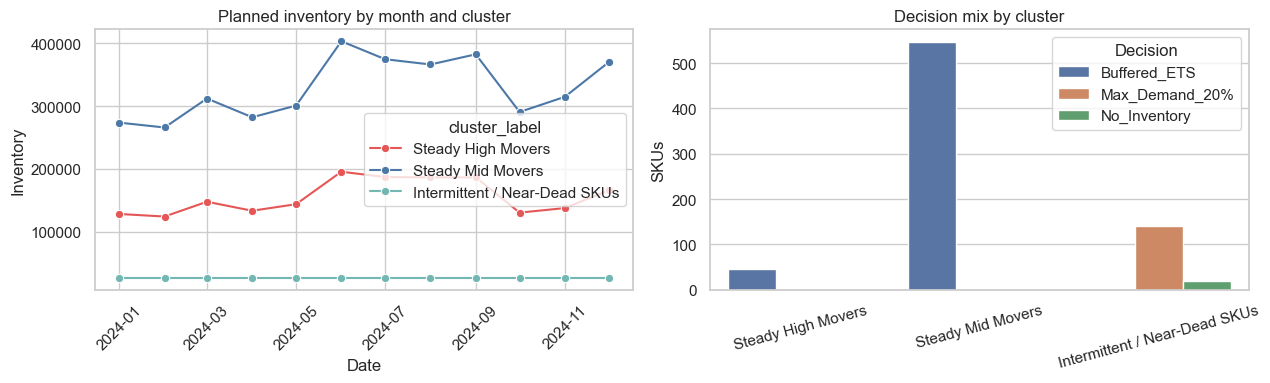

In [36]:
monthly_inventory_summary = (
    forecast_inventory_plan.groupby(["Date", "cluster_label"], dropna=False)
    .agg(total_inventory=("Inventory", "sum"))
    .reset_index()
)

decision_mix = (
    forecast_inventory_plan.groupby(["cluster_label", "Decision"], dropna=False)
    .agg(n_skus=("Sku", "nunique"))
    .reset_index()
)

decision_mix["cluster_label"] = pd.Categorical(
    decision_mix["cluster_label"],
    categories=cluster_label_order,
    ordered=True,
)
decision_mix = decision_mix.sort_values(["cluster_label", "Decision"]).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

sns.lineplot(
    data=monthly_inventory_summary,
    x="Date",
    y="total_inventory",
    hue="cluster_label",
    hue_order=cluster_label_order,
    palette=cluster_palette,
    marker="o",
    ax=axes[0],
)
axes[0].set_title("Planned inventory by month and cluster")
axes[0].set_xlabel("Date")
axes[0].set_ylabel("Inventory")
axes[0].tick_params(axis="x", rotation=45)

sns.barplot(
    data=decision_mix,
    x="cluster_label",
    y="n_skus",
    hue="Decision",
    order=cluster_label_order,
    ax=axes[1],
)
axes[1].set_title("Decision mix by cluster")
axes[1].set_xlabel("")
axes[1].set_ylabel("SKUs")
axes[1].tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()

In [37]:
forecast_inventory_plan.sort_values(["Sku", "Date"]).head(15)

,Sku,Date,cluster_label,Model,Forecast,Forecast_Buffer,Inventory,Decision
0,SKU_0001,2024-01-01,Steady Mid Movers,ETS,180.507211,226.0,226,Buffered_ETS
1,SKU_0001,2024-02-01,Steady Mid Movers,ETS,217.211926,263.0,263,Buffered_ETS
2,SKU_0001,2024-03-01,Steady Mid Movers,ETS,258.937636,305.0,305,Buffered_ETS
3,SKU_0001,2024-04-01,Steady Mid Movers,ETS,203.684812,250.0,250,Buffered_ETS
4,SKU_0001,2024-05-01,Steady Mid Movers,ETS,226.238207,272.0,272,Buffered_ETS
5,SKU_0001,2024-06-01,Steady Mid Movers,ETS,309.727961,356.0,356,Buffered_ETS
6,SKU_0001,2024-07-01,Steady Mid Movers,ETS,275.682299,322.0,322,Buffered_ETS
7,SKU_0001,2024-08-01,Steady Mid Movers,ETS,315.942961,362.0,362,Buffered_ETS
8,SKU_0001,2024-09-01,Steady Mid Movers,ETS,286.020321,332.0,332,Buffered_ETS
9,SKU_0001,2024-10-01,Steady Mid Movers,ETS,228.033528,274.0,274,Buffered_ETS


## Conclusion

This is the point where the project feels complete to me. The forecasts are no longer just model output. They turn into a planning table that someone could actually use.

The steady movers get a month-by-month buffered quantity from ETS. The intermittent group gets a more conservative standing rule, and a small subset drops all the way to no inventory because even the demand signal is too weak.

That is also the main takeaway from the project. The hard part was never just fitting a model. It was deciding what demand meant, separating different behaviors, validating the choices, and then translating all of that into something operational.

## Next steps

As a first introduction to forecasting in this process, this project can already have meaningful impact. But the real value comes from how these signals get absorbed into day-to-day operations.

The first next step is for the business to get familiar with the output and start translating it into actual decisions. That includes defining clearer reorder points, deciding when a forecast should trigger production, and setting practical rules for how the different demand groups should be handled.

From there, the forecasting layer can become more refined. Once the process is being used consistently, it makes more sense to test more complex models and check whether the added effort is really improving decisions.

There is also a useful extension on the classification side. Since the clustering step already groups SKUs by demand behavior, those labels can be used to train a simple decision tree or similar classifier. That would make it easier to assign new items into a demand segment early, even before enough history builds up to cluster them directly.